# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset: https://www.kaggle.com/datasets/wafaaelhusseini/wine-and-food-pairing-dataset/data?utm_ce=chatgpt.com&select=winefood__pairings.csv

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [25]:
# - Thought Process -
# Import pandas for data handling and seaborn/matplotlib for visualization.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('wine_food_pairings.csv')

# Use df.info() and isnull() to confirm there are no missing values (Nulls) and to ensure that pairing_quality is stored as a numerical type.

print("--- Dataset Summary ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34933 entries, 0 to 34932
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   wine_type        34933 non-null  object
 1   wine_category    34933 non-null  object
 2   food_item        34933 non-null  object
 3   food_category    34933 non-null  object
 4   cuisine          34933 non-null  object
 5   pairing_quality  34933 non-null  int64 
 6   quality_label    34933 non-null  object
 7   description      34933 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.1+ MB

--- Missing Values ---
wine_type          0
wine_category      0
food_item          0
food_category      0
cuisine            0
pairing_quality    0
quality_label      0
description        0
dtype: int64


## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [24]:
# === General Understanding of the dataset ===
# Use shape to confirm the total number of rows and columns,
print(f"Total number of rows: {df.shape[0]}")
print(f"Total number of columns: {df.shape[1]}")

# Get unique wine category count
num_categories = df['wine_category'].nunique()
print(f"Total Wine Categories: {num_categories}")

# Use aggregation to calculate the variety of wine_type within each category and 
# sort them to identify which categories offer the most selection.
wine_diversity = df.groupby('wine_category')['wine_type'].agg(['nunique', 'unique']) \
                   .sort_values(by='nunique', ascending=False) \
                   .rename(columns={'nunique': 'Count', 'unique': 'Wine types'})
print("\n--- Wine Diversity by Category (Sorted by Variety Count) ---")
print(wine_diversity)


# === Define the specific 5-course menu ===
party_menu =['caprese salad', 'cheese platter', 'roast lamb', 'grilled ribeye', 'gazpacho']

# Check the overall Top 3 (based on the entire dataset)
# This was my starting point to see which wines perform best overall.
overall_top_3 = df.groupby(['wine_category', 'wine_type'])['pairing_quality'].mean() \
                  .reset_index() \
                  .sort_values(by='pairing_quality', ascending=False) \
                  .head(3)

print("\n--- Overall Top 3 Wines (Complete Records) ---")
print(overall_top_3.to_string(index=False))

# Filter the dataframe for only my 5-course menu
party_df = df[df['food_item'].isin(party_menu)]

# Filter data for the 5 food items for the party.
# Calculate average scores by category and type to maintain wine labels.
# Sort and extract the 3 highest-rated wines for these pairings.
top_3_for_menu = df[df['food_item'].isin(party_menu)] \
                 .groupby(['wine_category', 'wine_type'])['pairing_quality'] \
                 .mean() \
                 .reset_index() \
                 .sort_values(by='pairing_quality', ascending=False) \
                 .head(3)

print("\n---Top 3 wines (specific to this menu)---:")
print(top_3_for_menu.to_string(index=False))

Total number of rows: 34933
Total number of columns: 8
Total Wine Categories: 6

--- Wine Diversity by Category (Sorted by Variety Count) ---
               Count                                         Wine types
wine_category                                                          
Red               12  [Syrah/Shiraz, Grenache, Cabernet Sauvignon, P...
White              9  [Viognier, Albariño, Grüner Veltliner, Rieslin...
Dessert            2                              [Sauternes, Ice Wine]
Fortified          2                                    [Madeira, Port]
Rosé               2                   [Provence Rosé, White Zinfandel]
Sparkling          2                                  [Cava, Champagne]

--- Overall Top 3 Wines (Complete Records) ---
wine_category          wine_type  pairing_quality
          Red        Tempranillo         3.138614
          Red Cabernet Sauvignon         3.093591
          Red       Syrah/Shiraz         3.092480

---Top 3 wines (specific to this 

In [27]:
# 1. Filter for menu & categories
pick_cats = ['Red', 'White', 'Dessert']
filtered_df = df[(df['food_item'].isin(party_menu)) & (df['wine_category'].isin(pick_cats))]

# 2. Calculate average score per type
avg_scores = filtered_df.groupby(['wine_category', 'wine_type'])['pairing_quality'].mean().reset_index()

# 3. Sort and pick the Top 1 per category
final_picks = avg_scores.sort_values(by='pairing_quality', ascending=False) \
                        .groupby('wine_category') \
                        .head(1) \
                        .reset_index(drop=True)

print(final_picks.to_string(index=False))

wine_category       wine_type  pairing_quality
          Red          Merlot         3.191304
      Dessert        Ice Wine         3.063401
        White Sauvignon Blanc         3.049536


## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

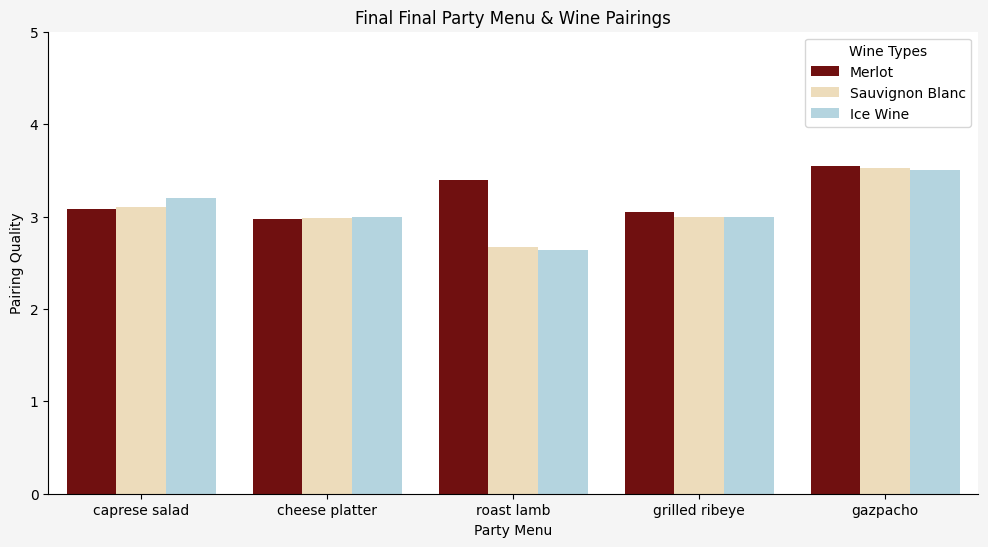

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('wine_food_pairings.csv')

# Define the specific 5-course menu and the top performing wine types.
party_menu =['caprese salad', 'cheese platter', 'roast lamb', 'grilled ribeye', 'gazpacho']
winners = ['Merlot', 'Sauvignon Blanc', 'Ice Wine']

# Filter for food items & wine types and pivot to ensure a complete 5x3 matrix for consistent plotting.
plot_df = df[df['food_item'].isin(party_menu) & df['wine_type'].isin(winners)].copy()
pivot_df = plot_df.pivot_table(index='food_item', columns='wine_type', values='pairing_quality', aggfunc='mean')
pivot_df = pivot_df.reindex(index=party_menu, columns=winners).fillna(0)
plot_ready = pivot_df.reset_index().melt(
    id_vars='food_item', 
    var_name='wine_type', 
    value_name='pairing_quality'
)

# Visual mappling: Establish a categorical color palette.
color_map = {
    'Merlot': 'maroon',
    'Sauvignon Blanc': 'wheat',
    'Ice Wine': 'lightblue'
}

# Initialized a wide-format figure with a neutral background for better readability.
# Plotted the bar chart using 'food_item' as the base and 'wine_type' as the hue to visualize pairing trends.
plt.figure(figsize=(12, 6), facecolor='whitesmoke')
ax = sns.barplot(data=plot_ready, x='food_item', y='pairing_quality', hue='wine_type', palette=color_map)

# Set formal titles and axis scales for standardized comparison.
plt.title('Final Party Menu & Wine Pairings')
plt.ylim(0, 5)

# Moved the legend (bbox_to_anchor) to ensure all bar data remains visible.
plt.legend(title='Wine Types', bbox_to_anchor=(1, 1))

plt.ylabel('Pairing Quality')
plt.xlabel('Party Menu')

# Removed top/right chart spines (sns.despine) to maximize the focus on data trends.
sns.despine()
plt.show()

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 
   
What surprised me most was the Dominance of Red Wines. If I simply selected the three wines with the highest average scores across the entire 5-course menu, all three winners would be red wines (Merlot, Syrah/Shiraz, and Tempranillo). This suggests that the chosen menu items have a strong overall affinity for the bold flavor of reds. 

However, to align with my primary analytical goal from Checkpoint 1， which was to ensure a more balanced and diverse wine selection, I selected the top-performing wine from each distinct category (Red, White, and Dessert), which resulted in the final selection of Merlot, Sauvignon Blanc, and Ice Wine.

2. Do you have any concerns about your dataset? 
   
My main concern is that because red wines show such a strong performance trend, the sample sizes for white and dessert wines might be smaller. I need to ensure that the "category winners" like Sauvignon Blanc and Ice Wine are backed by enough data points to be statistically meaningful.

3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 

Case sensitivity and whitespace: I noticed inconsistent capitalization in food_item (e.g., 'Indian Vindaloo' vs. 'Thai curry'). I need to apply a universal .str.lower() and .str.strip() to both food_item and wine_type columns to prevent omitting data in my average pairing quality calculation. This ensures that variations in casing or hidden trailing spaces don't split the same item into multiple categories.

Special character standardization: Entries like 'Riesling(dry)' and 'Syrah/Shiraz' contain parentheses and slashes. I need to investigate if these varietals are recorded under multiple formats (for example,'Syrah' vs. 'Syrah/Shiraz') and consolidate them to ensure accurate pivot_table aggregations.
